In [1]:
!python --version

Python 3.14.6


The system cannot find the path specified.


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import sem

In [69]:
# data = pd.read_csv(r"../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states.csv")

In [4]:

subset_taxa = data.loc[:, ["F01286", "F01287", "F01289", "F01290"]].drop_duplicates()
subset_taxa

,F01286,F01287,F01289,F01290
0,Abelia,biflora,Caprifoliaceae,Dipsacales
1,Abies,alba,Pinaceae,Pinales
2,Abies,fargesii,Pinaceae,Pinales
3,Abies,nephrolepis,Pinaceae,Pinales
4,Acacia,auriculiformis,Fabaceae,Fabales
...,...,...,...,...
990,Weinmannia,silvicola,Cunoniaceae,Oxalidales
991,Wendlandia,uvariifolia,Rubiaceae,Gentianales
992,Withania,frutescens,Solanaceae,Solanales
993,Xanthophyllum,tenue,Polygalaceae,Fabales


In [60]:
# summary of the paired independent ACEs for mycorrhizal states, RD and SRL
paired_changes = pd.read_csv(r"../../data/chapter2/FREDv3subset/deltalogaces995.csv")
paired_changes

,shifts,delta_rd,delta_srl
0,AM_to_AM,0.002481,0.006525
1,AM_to_AM,-0.054448,0.234665
2,AM_to_AM,0.031589,-0.056366
3,AM_to_AM,0.003544,-0.006095
4,AM_to_AM,0.070699,-0.072417
...,...,...,...
1983,AM_to_AM,-0.196324,0.735942
1984,AM_to_NMAM,0.035178,-0.582309
1985,NMAM_to_NMAM,-0.313497,0.131793
1986,NMAM_to_NMAM,0.363191,-0.954395


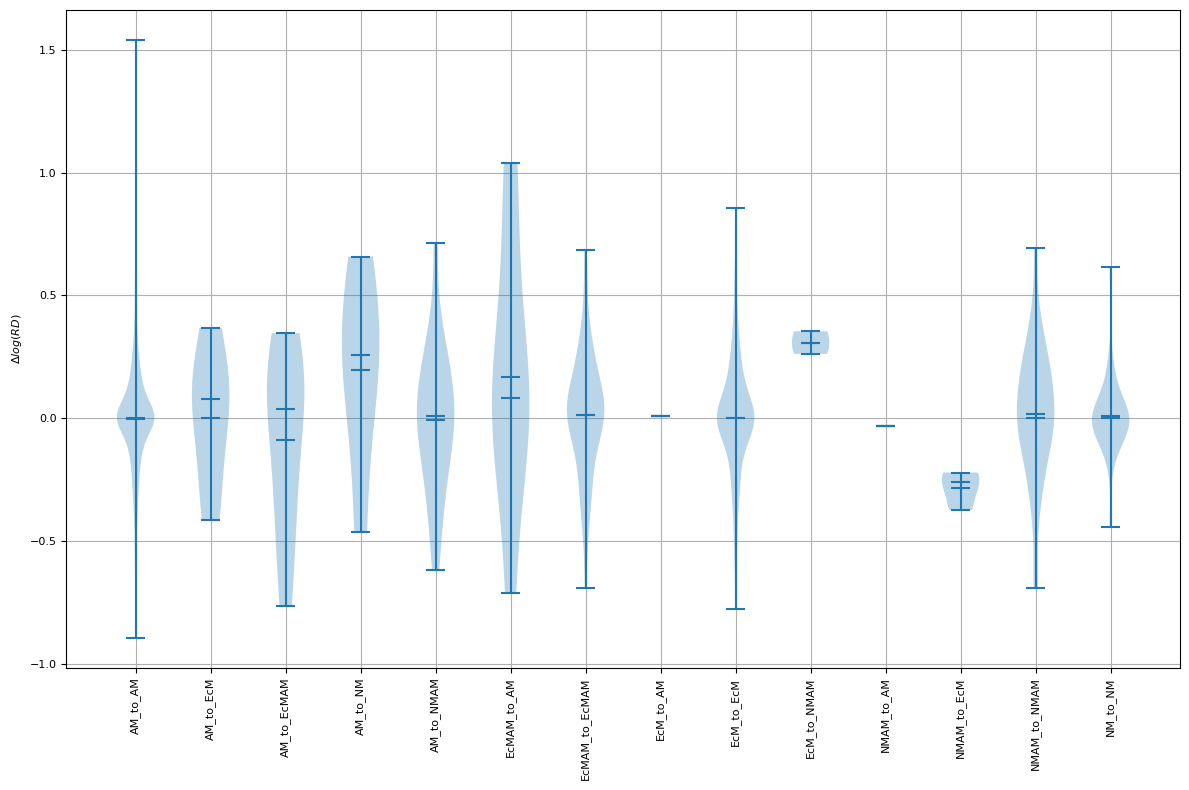

In [61]:
fig, axes = plt.subplots()
plt.rcParams["font.size"] = 10
fig.set_size_inches(12, 8)
axes.violinplot([df.delta_rd for (_, df) in paired_changes.groupby("shifts")], showmeans=True, showmedians=True)
axes.set_xticks(ticks=np.arange(start=1, stop=paired_changes.shifts.unique().size+1), labels=[_ for (_, df) in paired_changes.groupby("shifts")], rotation="vertical")
axes.grid()
axes.set_axisbelow(True)
axes.set_ylabel(r"$\Delta{log(RD)}$")
plt.tight_layout()
plt.show()

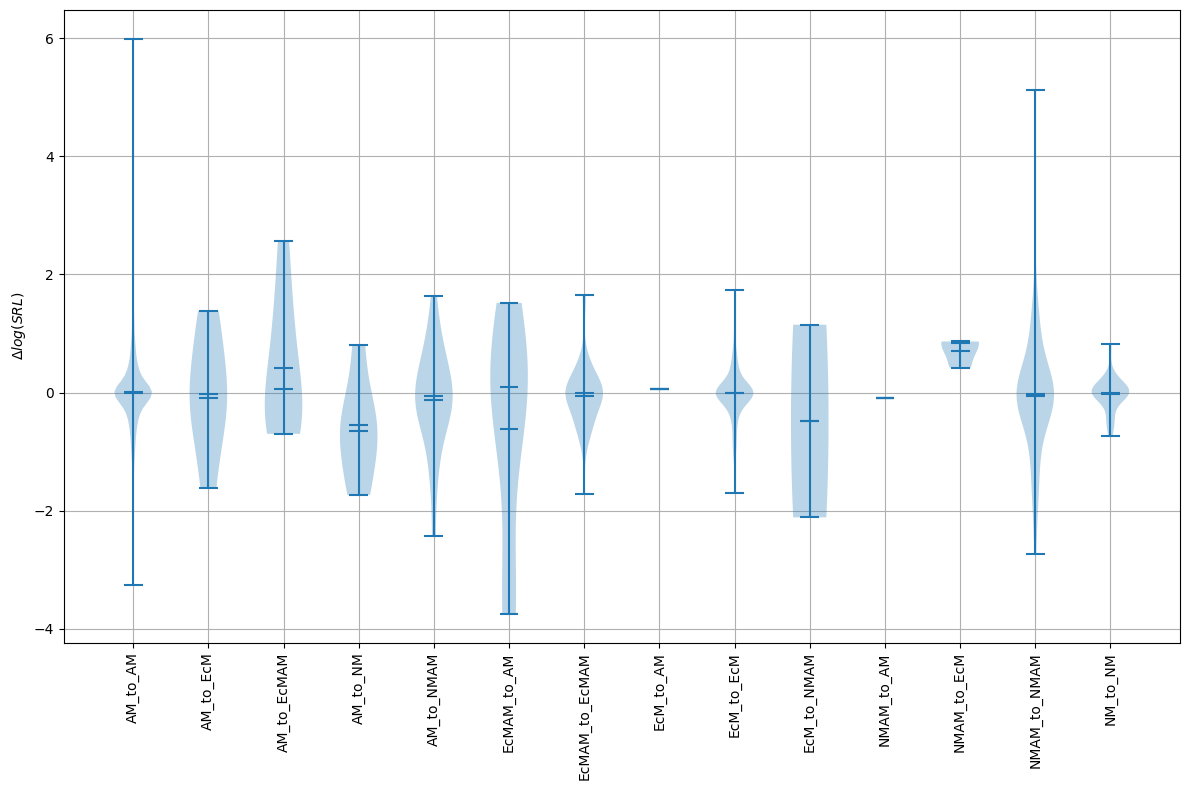

In [62]:
fig, axes = plt.subplots()
fig.set_size_inches(12, 8)
axes.violinplot([df.delta_srl for (_, df) in paired_changes.groupby("shifts")], showmeans=True, showmedians=True)
axes.set_xticks(ticks=np.arange(start=1, stop=paired_changes.shifts.unique().size+1), labels=[_ for (_, df) in paired_changes.groupby("shifts")], rotation="vertical")
axes.grid()
axes.set_axisbelow(True)
axes.set_ylabel(r"$\Delta{log(SRL)}$")
plt.tight_layout()
plt.show()

In [63]:
paired_changes.shifts.unique()

<StringArray>
[      'AM_to_AM',     'AM_to_NMAM',    'AM_to_EcMAM',    'EcMAM_to_AM',
       'AM_to_NM',   'NMAM_to_NMAM',      'AM_to_EcM',     'NMAM_to_AM',
    'NMAM_to_EcM',    'EcM_to_NMAM', 'EcMAM_to_EcMAM',     'EcM_to_EcM',
      'EcM_to_AM',       'NM_to_NM']
Length: 14, dtype: str

In [64]:
means = paired_changes.groupby("shifts", as_index=False).agg({"delta_rd": np.mean, "delta_srl": np.mean})
means

,shifts,delta_rd,delta_srl
0,AM_to_AM,-0.002274,0.008941
1,AM_to_EcM,0.001978,-0.027634
2,AM_to_EcMAM,-0.091020,0.407749
3,AM_to_NM,0.194559,-0.644674
4,AM_to_NMAM,-0.009204,-0.119138
5,EcMAM_to_AM,0.167204,-0.617152
6,EcMAM_to_EcMAM,0.012221,-0.052454
7,EcM_to_AM,0.008424,0.059974
8,EcM_to_EcM,0.001768,-0.002313
9,EcM_to_NMAM,0.307619,-0.482530


C:\Users\90963425\AppData\Local\Temp\ipykernel_16280\909550794.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels=axes.get_xticklabels(), rotation=90)


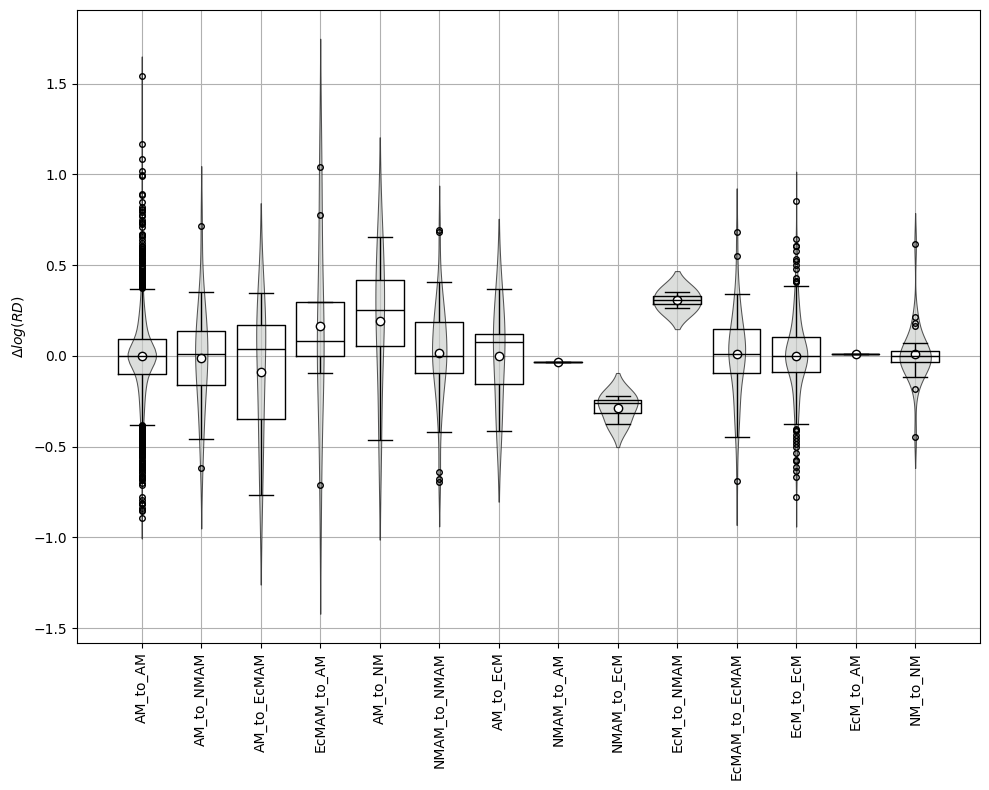

In [65]:
# may be seaborn will give more customization options
fig, axes = plt.subplots()
fig.set_size_inches(10, 8)
sns.violinplot(x=paired_changes.shifts, y=paired_changes.delta_rd, ax=axes, color="#CACDCA", fill=True, legend=False, saturation=1, linecolor="black", linewidth=0.75, inner=None, alpha=0.65)
sns.boxplot(x=paired_changes.shifts, y=paired_changes.delta_rd, orient="v", fill=False, linewidth=1, fliersize=4, color="black") #, showmeans=True, meanline=True,
           # medianprops={"color": "red", "linewidth": 1}), meanprops={"color": "blue", "linewidth": 1, "linestyle": "solid"})
axes.scatter(x=means.shifts, y=means.delta_rd, c="white", edgecolor="black")
axes.set_xticklabels(labels=axes.get_xticklabels(), rotation=90)
axes.set_ylabel(r"$\Delta{log(RD)}$")
axes.set_xlabel(None)
axes.grid()
axes.set_axisbelow(True)
plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/paired_independent_aces_rd.png", format="png", dpi=800, transparent=True)

C:\Users\90963425\AppData\Local\Temp\ipykernel_16280\1171613138.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels=axes.get_xticklabels(), rotation=90)


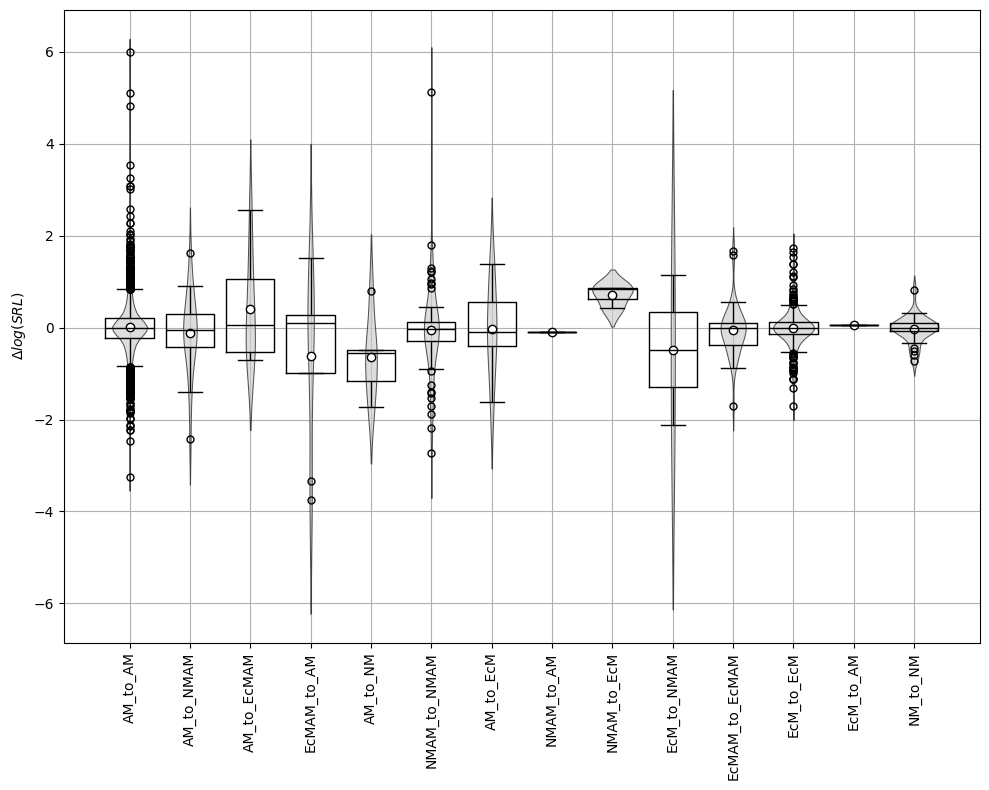

In [66]:
fig, axes = plt.subplots()
fig.set_size_inches(10, 8)
sns.violinplot(x=paired_changes.shifts, y=paired_changes.delta_srl, ax=axes, color="#CACDCA", fill=True, legend=False, saturation=1, linecolor="black", linewidth=0.75, inner=None, alpha=0.65)
sns.boxplot(x=paired_changes.shifts, y=paired_changes.delta_srl, orient="v", fill=False, color="black", linewidth=1, fliersize=5) #, showmeans=True, meanline=True,
           # medianprops={"color": "red", "linewidth": 1}, meanprops={"color": "blue", "linewidth": 1, "linestyle": "solid"})
axes.scatter(x=means.shifts, y=means.delta_srl, c="white", edgecolor="black")
axes.set_xticklabels(labels=axes.get_xticklabels(), rotation=90)
axes.set_ylabel(r"$\Delta{log(SRL)}$")
axes.set_xlabel(None)
axes.grid()
axes.set_axisbelow(True)
plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/paired_independent_aces_srl.png", format="png", dpi=800, transparent=True)

In [67]:
_rd = paired_changes.loc[:, ["shifts", "delta_rd"]].rename({"delta_rd": "value"}, axis=1)
_rd.insert(loc=2, column="trait", value="RD")

_srl = paired_changes.loc[:, ["shifts", "delta_srl"]].rename({"delta_srl": "value"}, axis=1)
_srl.insert(loc=2, column="trait", value="SRL")

_concat = pd.concat([_rd, _srl]) # so we can colour by the column "trait"

In [9]:
_concat

,shifts,value,trait
0,AM_to_AM,0.002481,RD
1,AM_to_AM,-0.054448,RD
2,AM_to_AM,0.031589,RD
3,AM_to_AM,0.003544,RD
4,AM_to_AM,0.070699,RD
...,...,...,...
1983,AM_to_AM,0.735942,SRL
1984,AM_to_NMAM,-0.582309,SRL
1985,NMAM_to_NMAM,0.131793,SRL
1986,NMAM_to_NMAM,-0.954395,SRL


C:\Users\90963425\AppData\Local\Temp\ipykernel_16280\951947054.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels=axes.get_xticklabels(), rotation=90)


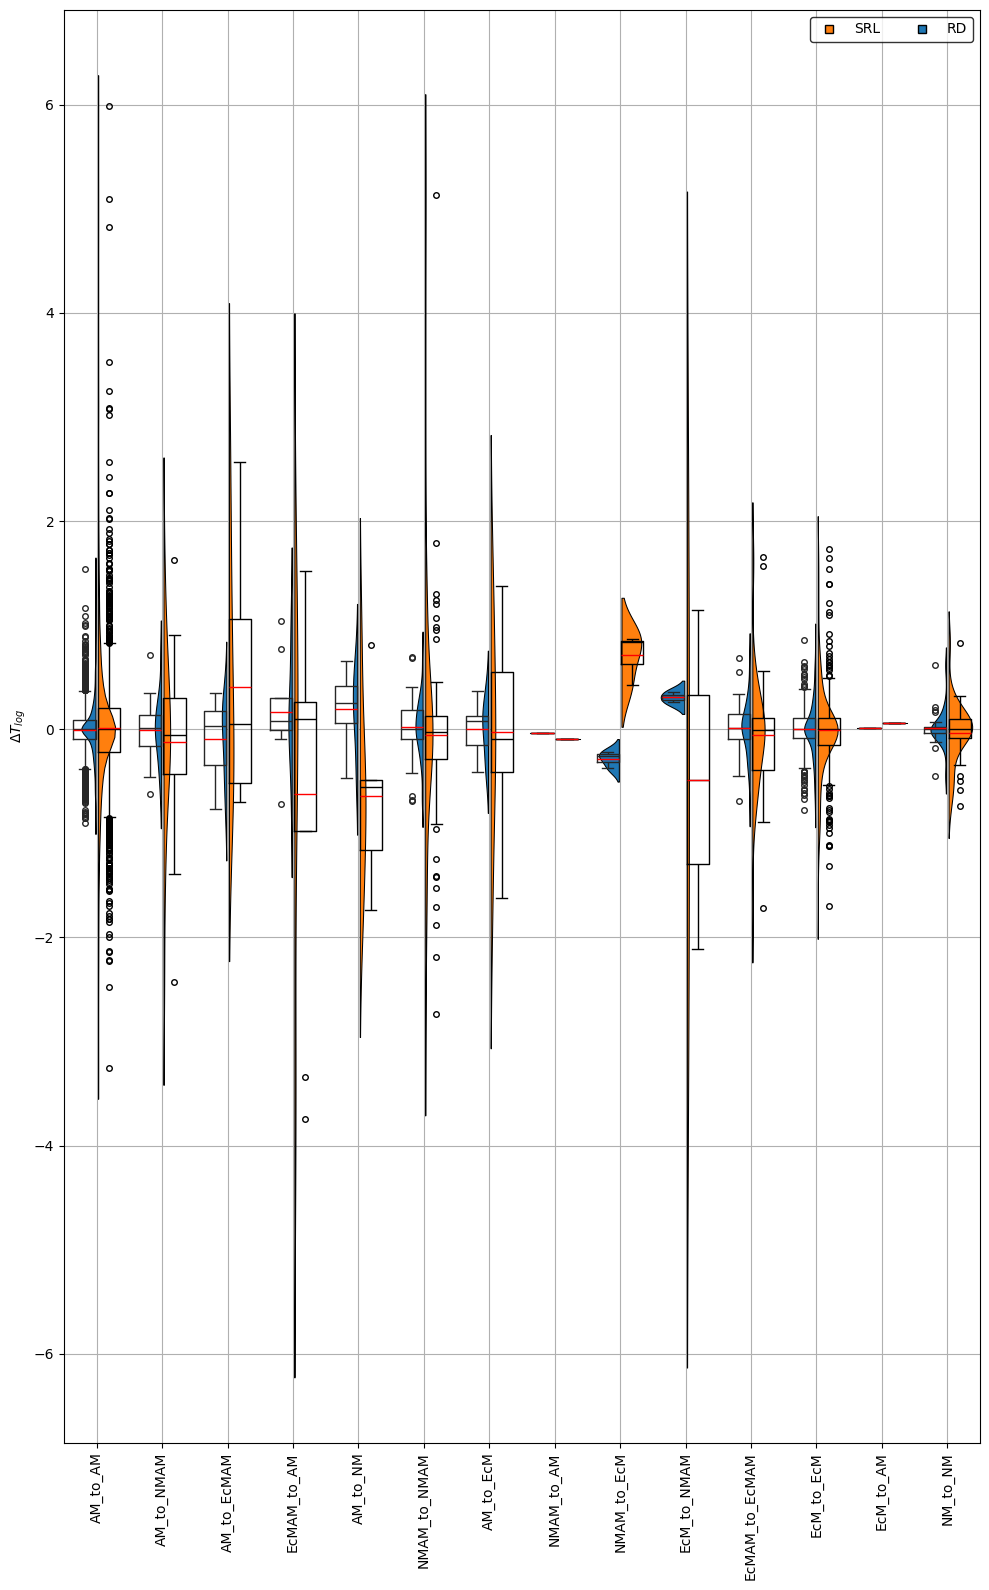

In [72]:
# try showing the ACEs of Rd & SRL side by side

fig, axes = plt.subplots()
fig.set_size_inches(10, 16)

sns.violinplot(data=_concat, x="shifts", y="value", hue="trait", ax=axes, fill=True, legend=False, saturation=1, linecolor="black", linewidth=0.75, inner=None, split=True, gap=0.1)
sns.boxplot(data=_concat, x="shifts", y="value", hue="trait", orient="v", fill=False, palette="dark:black", linewidth=1, fliersize=4, gap=0.1, width=0.75, showmeans=True, meanline=True,
            meanprops=dict(color="red", linestyle="-"))

axes.set_xticklabels(labels=axes.get_xticklabels(), rotation=90)
axes.set_ylabel(r"$\Delta{T_{log}}$")
axes.set_xlabel(None)
axes.legend(edgecolor="black", ncols=2, loc="upper right", handles=[Line2D(xdata=[0], ydata=[0], marker='s', markeredgecolor="black", markerfacecolor="#FF7F0E", label="SRL", linestyle="none"),
                                                             Line2D(xdata=[0], ydata=[0], marker='s', markeredgecolor="black", markerfacecolor="#1F77B4", label="RD", linestyle="none")])

axes.grid()
axes.set_axisbelow(True)
plt.tight_layout()
# plt.show()
plt.savefig(r"../../plots/paired_independent_aces_all.png", format="png", dpi=1000, transparent=True)

In [15]:
# hOUwie summaries

summary = pd.read_csv(r"../../data/chapter2/hOUwie_summary.csv")#.drop(["expected_mean", "expected_var"], axis=0)
summary

,Unnamed: 0,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state,trait,cd
0,Rudbeckia_hirta,0.001403,0.164760,0.076897,-1.059271,-1.059271,0.233338,AM,RD,True
1,Ratibida_pinnata,0.001403,0.164760,0.076897,-1.059271,-1.059271,0.233338,AM,RD,True
2,Heliopsis_helianthoides,0.000222,0.164760,0.083065,-1.408530,-1.393259,0.252842,NM,RD,True
3,Liatris_aspera,0.001403,0.164760,0.076897,-1.059271,-1.059271,0.233338,AM,RD,True
4,Arnica_sororia,0.001403,0.164760,0.076897,-1.059271,-1.059271,0.233338,AM,RD,True
...,...,...,...,...,...,...,...,...,...,...
3975,Dicranopteris_linearis3,0.001317,0.061198,0.172946,3.795347,3.795347,1.412999,AM,SRL,False
3976,Osmunda_japonica3,0.001317,0.061198,0.172946,3.795347,3.795347,1.412999,AM,SRL,False
3977,Equisetum_hyemale3,0.001317,0.061198,0.172946,3.795347,3.795347,1.412999,NMAM,SRL,False
3978,Equisetum_pratense3,0.001317,0.061198,0.172946,3.795347,3.795347,1.412999,NMAM,SRL,False


In [4]:
summary = summary.drop(["expected_mean", "expected_var"], axis=1).rename({"Unnamed: 0": "binominal"}, axis=1)
summary

,binominal,rates,alpha,sigma.sq,theta,tip_state,trait,cd
0,Rudbeckia_hirta,0.001403,0.164760,0.076897,-1.059271,AM,RD,True
1,Ratibida_pinnata,0.001403,0.164760,0.076897,-1.059271,AM,RD,True
2,Heliopsis_helianthoides,0.000222,0.164760,0.083065,-1.408530,NM,RD,True
3,Liatris_aspera,0.001403,0.164760,0.076897,-1.059271,AM,RD,True
4,Arnica_sororia,0.001403,0.164760,0.076897,-1.059271,AM,RD,True
...,...,...,...,...,...,...,...,...
3975,Dicranopteris_linearis3,0.001317,0.061198,0.172946,3.795347,AM,SRL,False
3976,Osmunda_japonica3,0.001317,0.061198,0.172946,3.795347,AM,SRL,False
3977,Equisetum_hyemale3,0.001317,0.061198,0.172946,3.795347,NMAM,SRL,False
3978,Equisetum_pratense3,0.001317,0.061198,0.172946,3.795347,NMAM,SRL,False


In [113]:
def plot_houwie_summary(data: pd.DataFrame,
                        trait: str,
                        width: int = 10,
                        height: int = 10,
                        meanprops_cd: dict[str, str] = {"marker": 'o', "markerfacecolor": "red", "markeredgecolor": "black"},
                        meanprops_cid: dict[str, str] = {"marker": 'o', "markerfacecolor": "blue", "markeredgecolor": "black"},
                        flierprops_cd = {'marker': 'o', 'markerfacecolor': "none", "markeredgecolor": "red"}, # for outliers
                        flierprops_cid = {'marker': 'o', 'markerfacecolor': "none", "markeredgecolor": "blue"},
                        medianprops_cd: dict[str, str]|None = None,
                        medianprops_cid: dict[str, str]|None = None
                       ) -> None:
    
    METRICS_AND_LATEX_SYMBOLS = { "rates": "Rates", "alpha": r"$\alpha$", "sigma.sq": r"$\sigma^{2}$", "theta": r"$\theta$" } # LaTex symbols for some of the model estimates
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=False)
    fig.set_size_inches(width, height)

    _cd = data.query(f"trait=='{trait}' and cd==True")
    _cid = data.query(f"trait=='{trait}' and cd==False")
    
    for (axis, col) in zip(axes.flatten(), METRICS_AND_LATEX_SYMBOLS):
    
        axis.boxplot([df.loc[:, col] for (_, df) in _cd.groupby("tip_state")], showmeans=True, meanprops=meanprops_cd, medianprops=medianprops_cd, flierprops=flierprops_cd)
        axis.boxplot([df.loc[:, col] for (_, df) in _cid.groupby("tip_state")], showmeans=True, meanprops= meanprops_cid, medianprops=medianprops_cid, flierprops=flierprops_cid)
    
        axis.set_xticks(ticks=np.arange(1, data.tip_state.unique().size + 1), labels=[_ for (_, df) in _cd.groupby("tip_state")]) # set it last manually, instead of through axes.boxplot() each time
        axis.set_ylabel(METRICS_AND_LATEX_SYMBOLS.get(col))
        axis.grid()
        axis.set_axisbelow(True)

    fig.supxlabel(f"${trait}$")
    fig.legend(edgecolor="black", ncols=2, loc="upper right", handles=[Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="red", label="CD", linestyle="none"),
                                                             Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="blue", label="CID", linestyle="none")])
    plt.tight_layout()
    

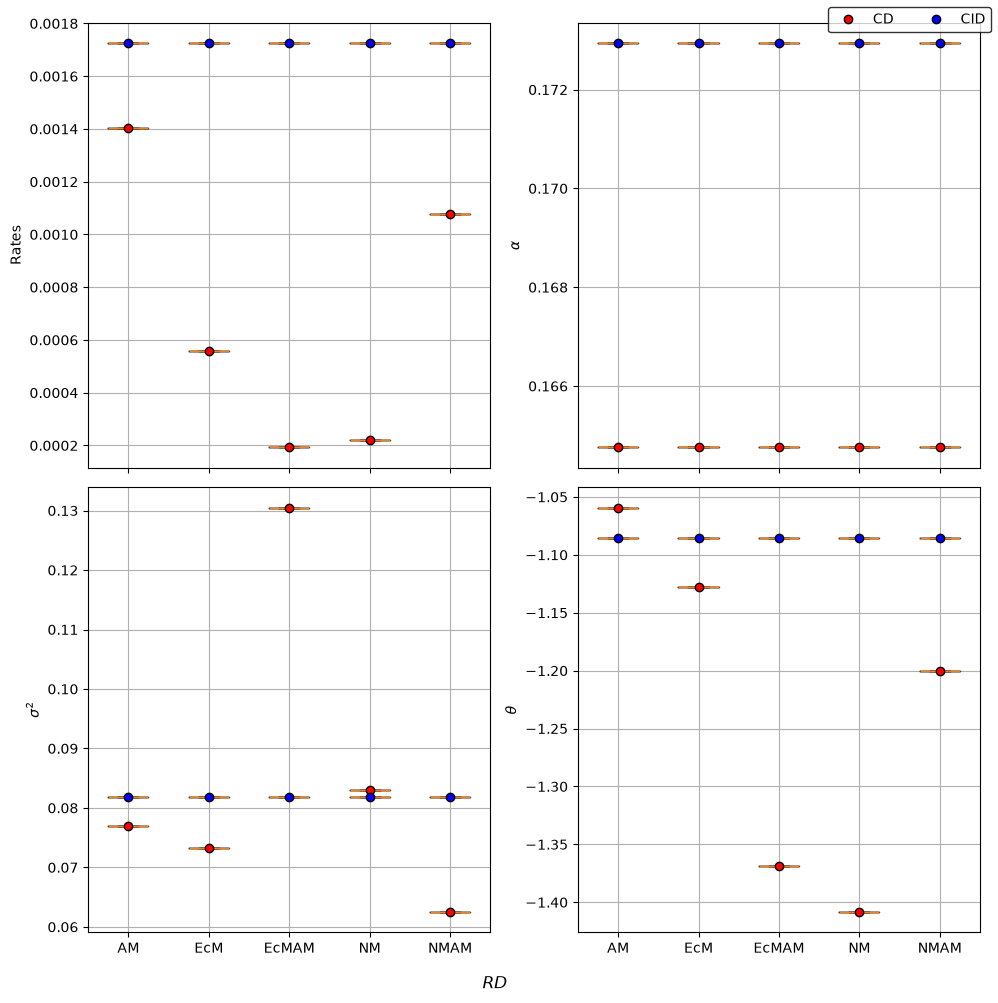

In [114]:
plot_houwie_summary(data=summary, trait="RD")
plt.show()

# plt.savefig(r"../../plots/houwie_summary_rd_995sp_100sims.png", format="png", dpi=800, transparent=True)

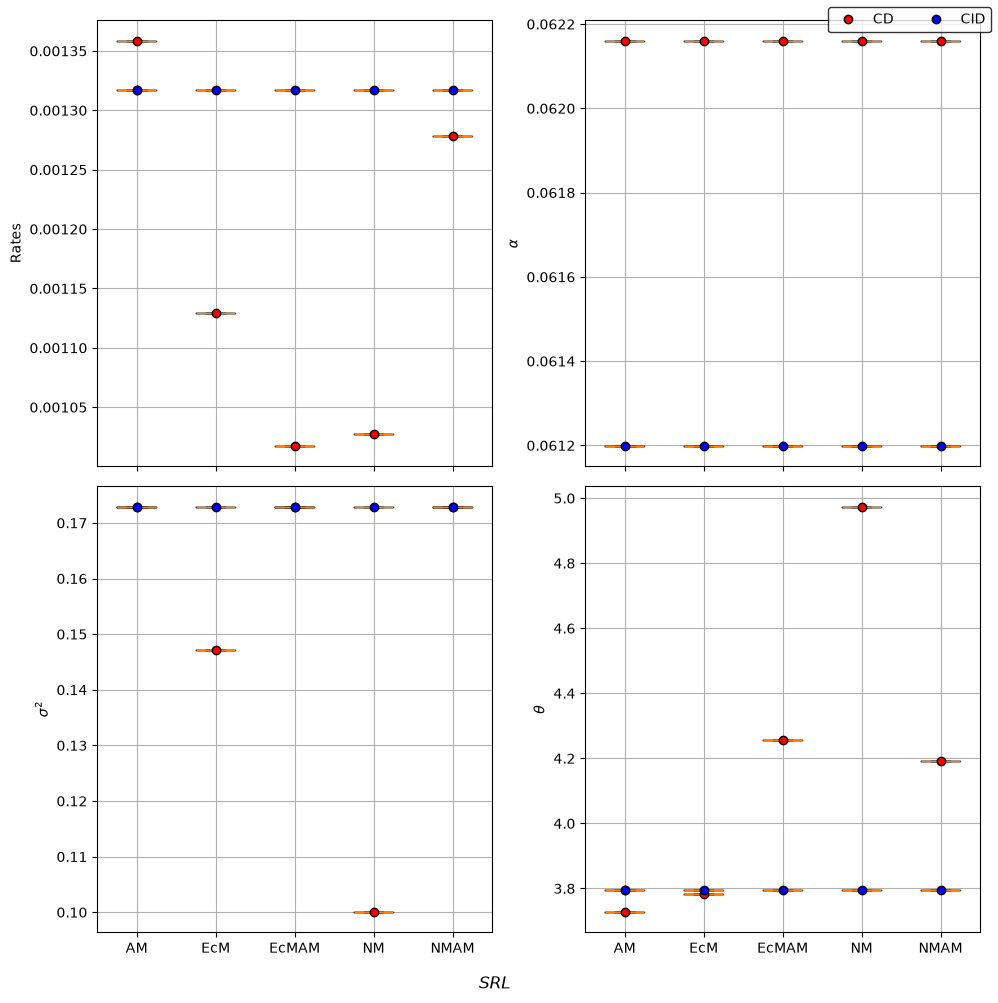

In [115]:
plot_houwie_summary(data=summary, trait="SRL")
plt.show()
# plt.savefig(r"../../plots/houwie_summary_srl_995sp_100sims.png", format="png", dpi=800, transparent=True)

In [8]:
# visualize the AICcs of all the fits

aicc_summary = pd.read_csv(r"../../data/chapter2/hOUwie_aicc_model_tables_995sp_100sims.csv")

# aicc_summary.columns = ("RDcd", "RDcid", "SRLcd", "SRLcid")
# aicc_summary.drop(0, axis=0, inplace=True)
# aicc_summary = aicc_summary.astype({"RDcd": np.float64, "RDcid": np.float64, "SRLcd": np.float64, "SRLcid": np.float64})
aicc_summary

,RDcd,RDcid,SRLcd,SRLcid,model
0,1731.126570,1828.678591,3853.193849,4657.794950,ARDOUM
1,2545.539947,2693.022525,4487.405877,4448.731190,ARDOUMA
2,1815.817414,2669.462327,4507.848087,4598.386563,ARDOUMV
3,2501.529278,2655.075915,4401.705061,4271.710374,ARDOUMVA
4,2631.131421,1733.091556,3825.114095,4546.480356,EROUM
5,2532.583882,NaN,4493.564511,NaN,EROUMA
6,2501.813909,1763.871572,3821.690085,3845.076764,EROUMV
7,2474.716133,NaN,4428.694297,4309.044363,EROUMVA
8,1716.898024,1824.136491,3823.263494,3892.906239,SYMOUM
9,2523.120150,2576.054586,5251.342963,NaN,SYMOUMA


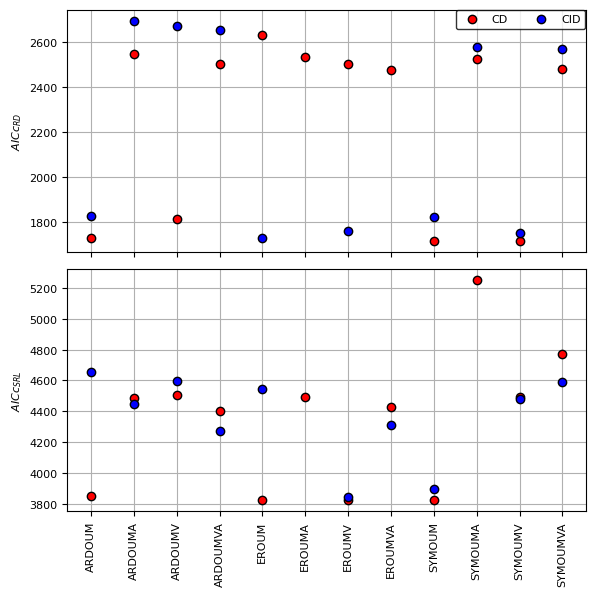

In [9]:
plt.rcParams["font.size"] = 8
fig, (axis_0, axis_1) = plt.subplots(nrows=2, sharex=True)
fig.set_size_inches(6, 6)

axis_0.scatter(x=aicc_summary.model, y=aicc_summary.RDcd, c="red", edgecolor="black")
axis_0.scatter(x=aicc_summary.model, y=aicc_summary.RDcid, c="blue", edgecolor="black")
axis_0.grid()
axis_0.set_axisbelow(True)
axis_0.set_ylabel(r"$AICc_{RD}$")

axis_1.scatter(x=aicc_summary.model, y=aicc_summary.SRLcd, c="red", edgecolor="black")
axis_1.scatter(x=aicc_summary.model, y=aicc_summary.SRLcid, c="blue", edgecolor="black")
axis_1.grid()
axis_1.set_axisbelow(True)
axis_1.set_ylabel(r"$AICc_{SRL}$")
axis_1.set_xticks(labels=aicc_summary.model, ticks=np.arange(start=0, stop=aicc_summary.model.size), rotation=90)

fig.legend(edgecolor="black", ncols=2, loc=(0.765, 0.95), handles=[Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="red", label="CD", linestyle="none"),
                                                             Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="blue", label="CID", linestyle="none")])
plt.tight_layout()
# plt.show()
plt.savefig(fname=r"../../plots/houwie_model_summary_100sims.png", format="png", dpi=800, bbox_inches="tight", transparent=True)

In [199]:
# looks like we need to drop the convergence failures - the data points with extremely low AICcs

In [21]:
data = pd.read_csv(r"../../data/chapter2/ModelAvgParams_1301sp_250sims.csv")
data.head()

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state,trait,cd
0,0.001397,0.031881,0.172946,-0.874531,-0.874531,1.073704e+10,AM,RD,True
1,0.001397,0.031881,0.172946,-0.874531,-0.874539,5.181933e+09,AM,RD,True
2,0.001397,0.031881,0.172946,-0.874531,-0.874544,3.043808e+09,AM,RD,True
3,0.001397,0.031881,0.172946,-0.874531,-0.874538,5.585084e+09,AM,RD,True
4,0.001397,0.031881,0.172946,-0.874531,-0.874538,5.585084e+09,AM,RD,True


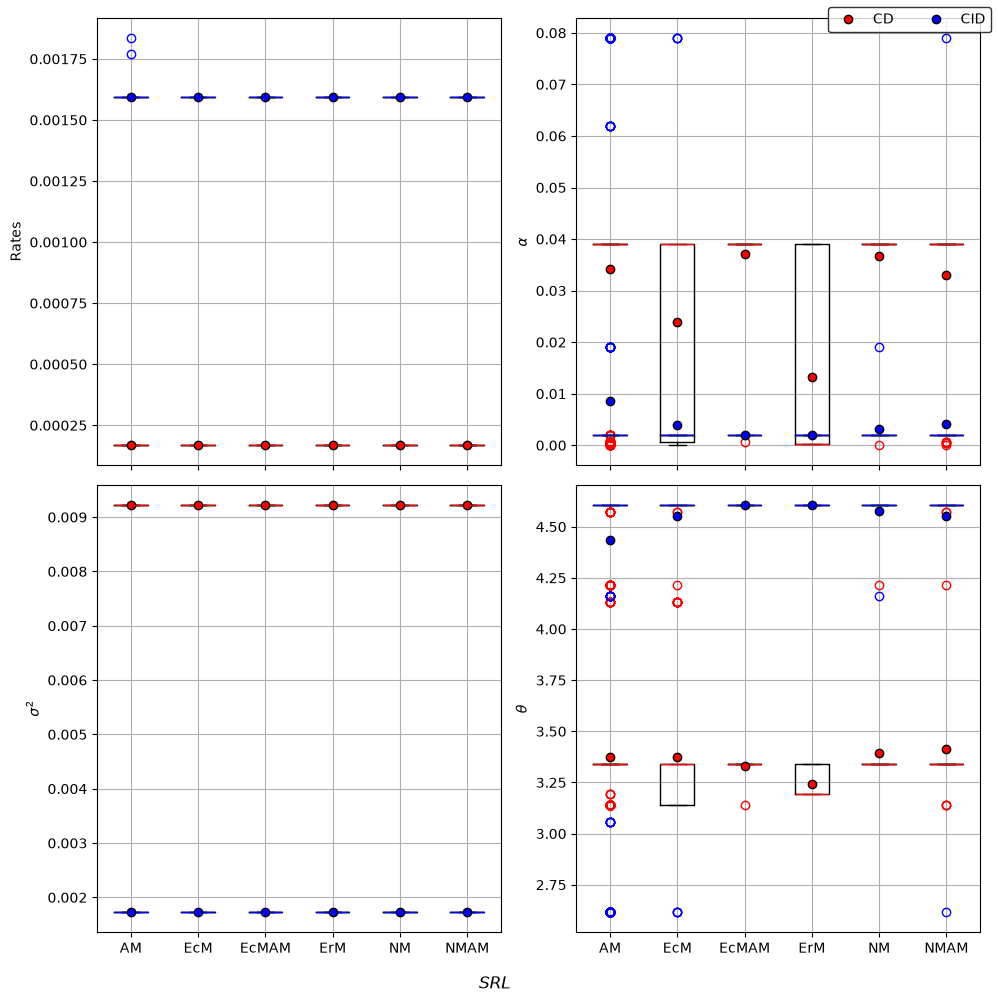

In [118]:
plot_houwie_summary(data=data, trait="SRL", medianprops_cd={"color": "red"}, medianprops_cid={"color": "blue"})

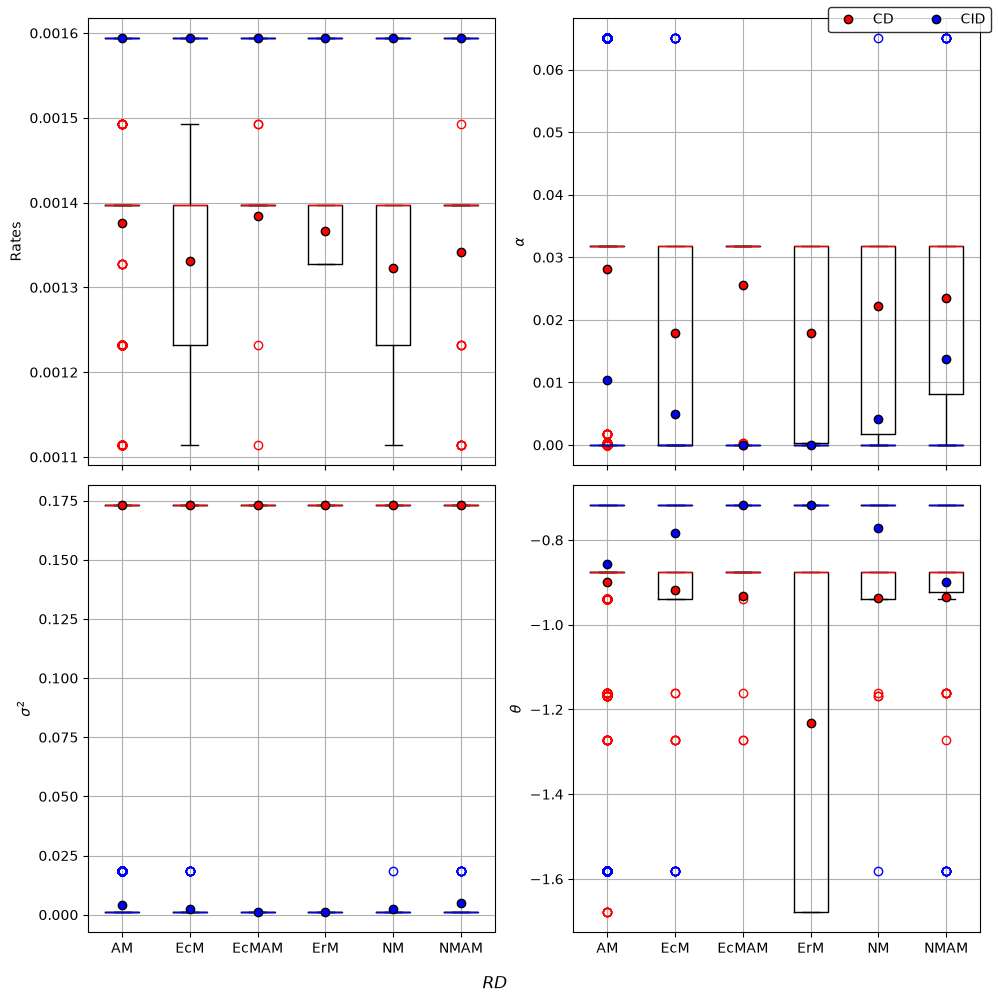

In [117]:
plot_houwie_summary(data=data, trait="RD", medianprops_cd={"color": "red"}, medianprops_cid={"color": "blue"})

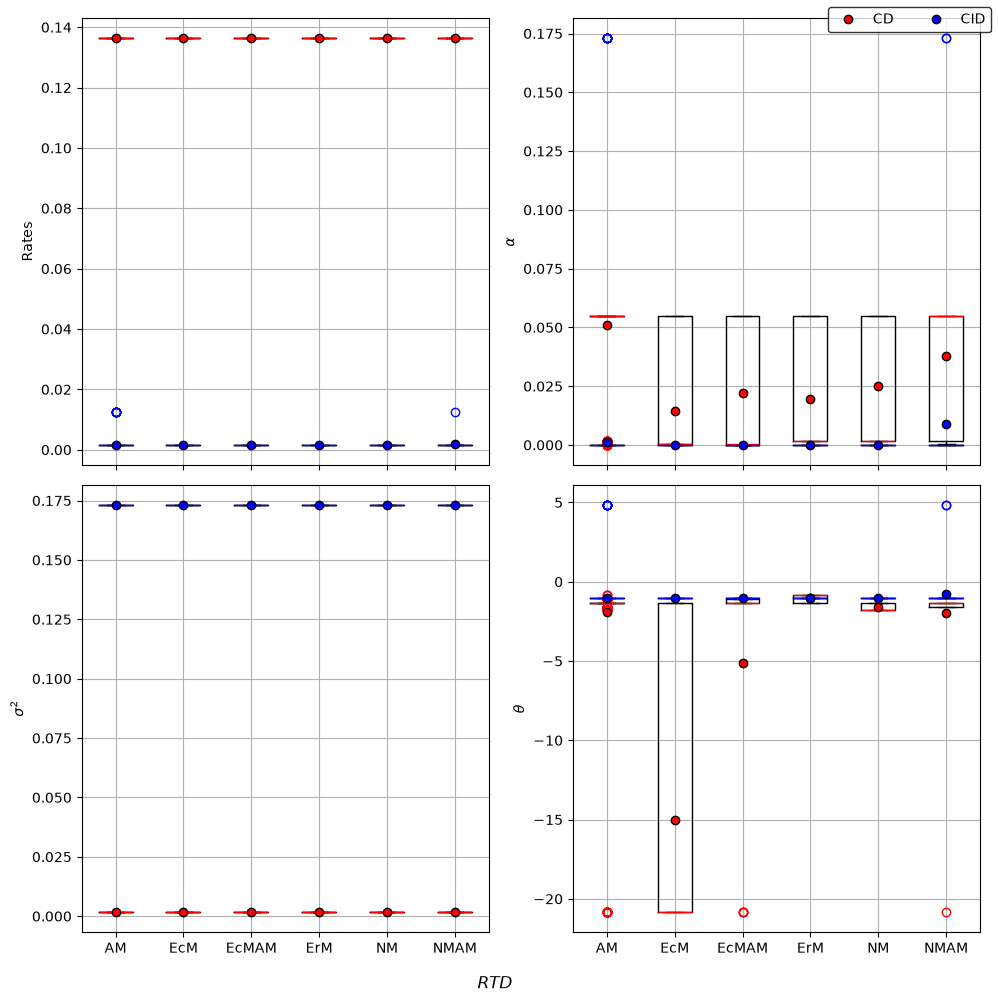

In [116]:
plot_houwie_summary(data=data, trait="RTD", medianprops_cd={"color": "red"}, medianprops_cid={"color": "blue"})

In [43]:
rd_subset = data.query(r"trait=='RD'")
rd_subset.head()

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state,trait,cd
0,0.001397,0.031881,0.172946,-0.874531,-0.874531,1.073704e+10,AM,RD,True
1,0.001397,0.031881,0.172946,-0.874531,-0.874539,5.181933e+09,AM,RD,True
2,0.001397,0.031881,0.172946,-0.874531,-0.874544,3.043808e+09,AM,RD,True
3,0.001397,0.031881,0.172946,-0.874531,-0.874538,5.585084e+09,AM,RD,True
4,0.001397,0.031881,0.172946,-0.874531,-0.874538,5.585084e+09,AM,RD,True


In [73]:
rd_subset.groupby(["cd", "tip_state"]).agg({"rates": sem, "alpha": sem, "sigma.sq": sem, "theta": sem})

rates         alpha      sigma.sq         theta
cd    tip_state                                                        
False AM         6.549905e-21  7.185324e-04  1.931359e-04  9.555891e-03
      EcM        3.958947e-20  1.556066e-03  4.182584e-04  2.069440e-02
      EcMAM      4.974661e-20  1.554581e-21  4.974661e-20  2.547026e-17
      ErM        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
      NM         0.000000e+00  4.060259e-03  1.091366e-03  5.399812e-02
      NMAM       7.129670e-20  4.354065e-03  1.170339e-03  5.790549e-02
True  AM         2.014000e-06  3.068980e-04  8.383878e-19  2.655926e-03
      EcM        8.074470e-06  1.442868e-03  5.067452e-18  7.283267e-03
      EcMAM      1.789634e-05  2.911028e-03  6.367566e-18  2.974876e-02
      ErM        1.203001e-05  5.546944e-03  0.000000e+00  1.412019e-01
      NM         2.935009e-05  3.733508e-03  0.000000e+00  2.893125e-02
      NMAM       1.795613e-05  2.304756e-03  9.125977e-18  1.927719e-02

In [81]:
rd_subset.query(r"cd").groupby("tip_state", as_index=False).agg({"rates": sem})

,tip_state,rates
0,AM,0.000002
1,EcM,0.000008
2,EcMAM,0.000018
3,ErM,0.000012
4,NM,0.000029
5,NMAM,0.000018


In [112]:
rd_subset.query(r"cd").groupby("tip_state", as_index=False).agg({"rates": "mean"})#["rates"]

,tip_state,rates
0,AM,0.001376
1,EcM,0.001331
2,EcMAM,0.001384
3,ErM,0.001366
4,NM,0.001323
5,NMAM,0.001342


In [108]:
rd_subset.query(r"not cd")

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state,trait,cd
1301,0.001594,0.000036,0.001123,-0.718342,-0.718342,4.437705e-01,AM,RD,False
1302,0.001594,0.065000,0.018585,-1.582312,-1.582312,1.693268e+16,AM,RD,False
1303,0.001594,0.065000,0.018585,-1.582312,-1.582312,1.693268e+16,AM,RD,False
1304,0.001594,0.065000,0.018585,-1.582312,-1.582312,1.693268e+16,AM,RD,False
1305,0.001594,0.065000,0.018585,-1.582312,-1.582312,1.693268e+16,AM,RD,False
...,...,...,...,...,...,...,...,...,...
2597,0.001594,0.000036,0.001123,-0.718342,-0.718342,4.437705e-01,AM,RD,False
2598,0.001594,0.000036,0.001123,-0.718342,-0.718342,4.437705e-01,AM,RD,False
2599,0.001594,0.065000,0.018585,-1.582312,-1.582312,1.693268e+16,NMAM,RD,False
2600,0.001594,0.065000,0.018585,-1.582312,-1.582312,1.693268e+16,NMAM,RD,False


In [133]:
def plot_houwie_summary_v2(data: pd.DataFrame, trait: str, width: int = 10, height: int = 10, ccd: str = "red", ccid: str = "blue") -> None:
    
    METRICS_AND_LATEX_SYMBOLS = { "rates": "Rates", "alpha": r"$\alpha$", "sigma.sq": r"$\sigma^{2}$", "theta": r"$\theta$" }
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=False)
    fig.set_size_inches(width, height)

    subset_cd = data.query(f"trait=='{trait}' and cd==True")
    subset_cid = data.query(f"trait=='{trait}' and cd==False")
    
    for (axis, col) in zip(axes.flatten(), METRICS_AND_LATEX_SYMBOLS):
        
        axis.scatter(x=subset_cd.tip_state, y=subset_cd.rates, ec=ccd, fc="none")
        axis.errorbar(
            x=subset_cd.groupby("tip_state", as_index=False).agg({col: "mean"})["tip_state"], # states as thex axis
            y=subset_cd.groupby("tip_state", as_index=False).agg({col: "mean"})[col], # mean of the metric as the y axis
            yerr=subset_cd.groupby("tip_state", as_index=False).agg({col: sem})[col], # standard error of the metric for error bars
            fmt='o', ecolor="black", capsize=7.5, elinestyle="-", mfc=ccd, mec="black"
        )

        axis.scatter(x=subset_cid.tip_state, y=subset_cid.rates, ec=ccid, fc="none")
        axis.errorbar(
            x=subset_cid.groupby("tip_state", as_index=False).agg({col: "mean"})["tip_state"],
            y=subset_cid.groupby("tip_state", as_index=False).agg({col: "mean"})[col],
            yerr=subset_cid.groupby("tip_state", as_index=False).agg({col: sem})[col], fmt='o', ecolor="black", capsize=7.5, elinestyle="-", mfc=ccid, mec="black"
        )
        
        
        axis.set_ylabel(METRICS_AND_LATEX_SYMBOLS.get(col))
        axis.grid()
        axis.set_axisbelow(True)

    fig.supxlabel(f"${trait}$")
    fig.legend(edgecolor="black", ncols=2, loc="lower right", handles=[Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="red", label="CD", linestyle="none"),
                Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="blue", label="CID", linestyle="none")])
    plt.tight_layout()
    

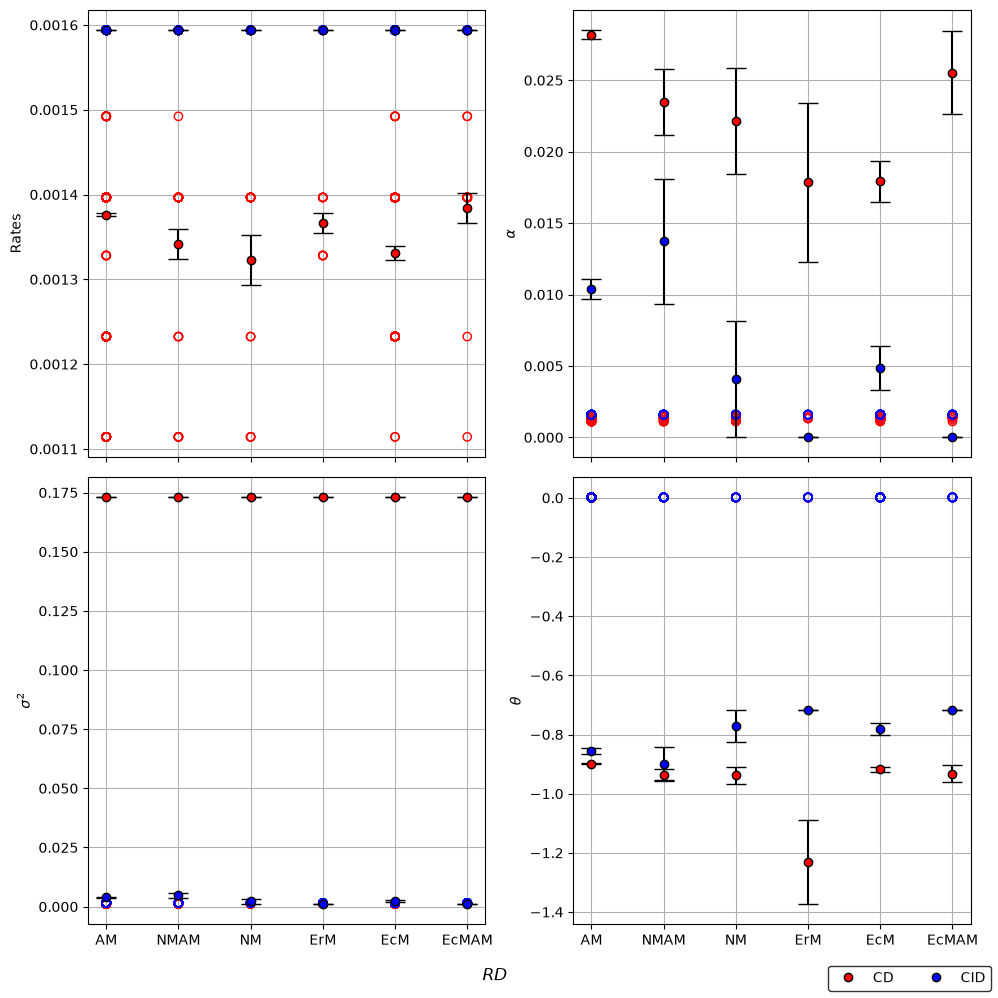

In [137]:
plot_houwie_summary_v2(data=data, trait="RD")
plt.savefig(r"../../plots/houwieRD1301_250sims.png", format="png", dpi=800, transparent=True)

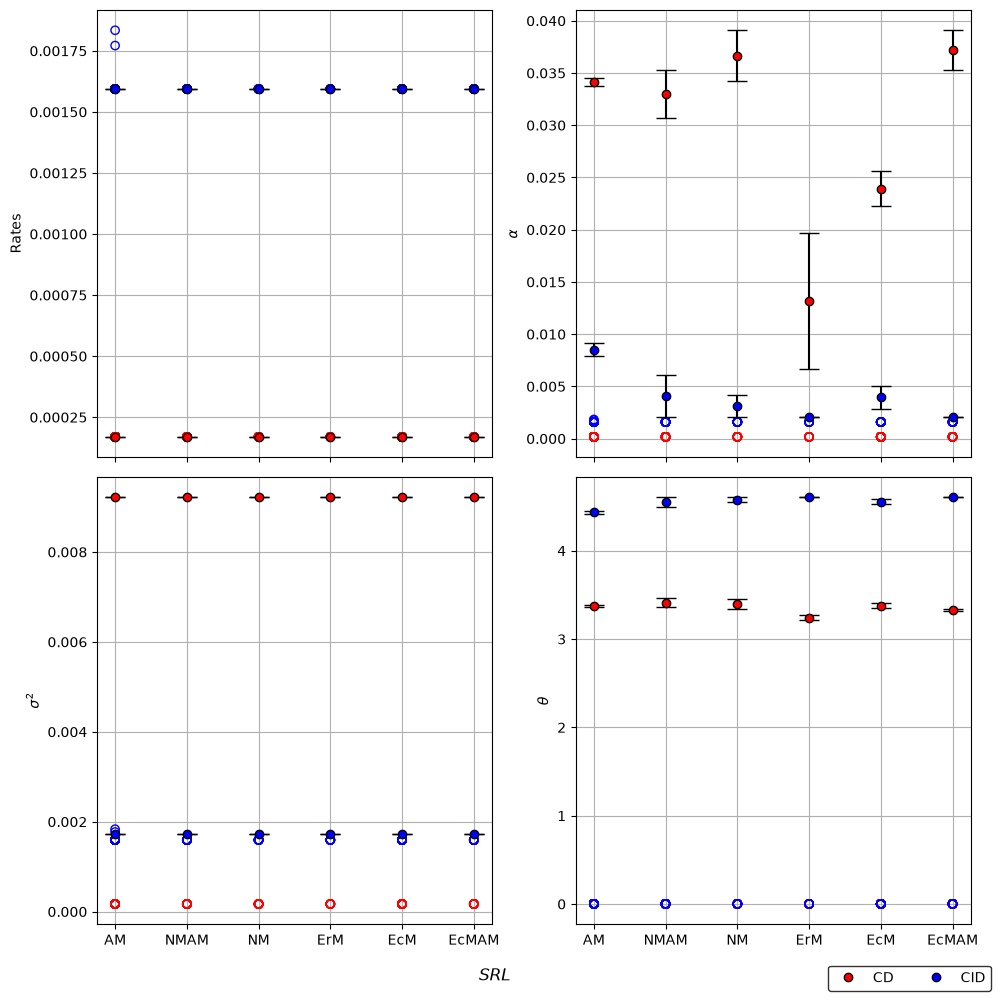

In [138]:
plot_houwie_summary_v2(data=data, trait="SRL")
plt.savefig(r"../../plots/houwieSRL1301_250sims.png", format="png", dpi=800, transparent=True)

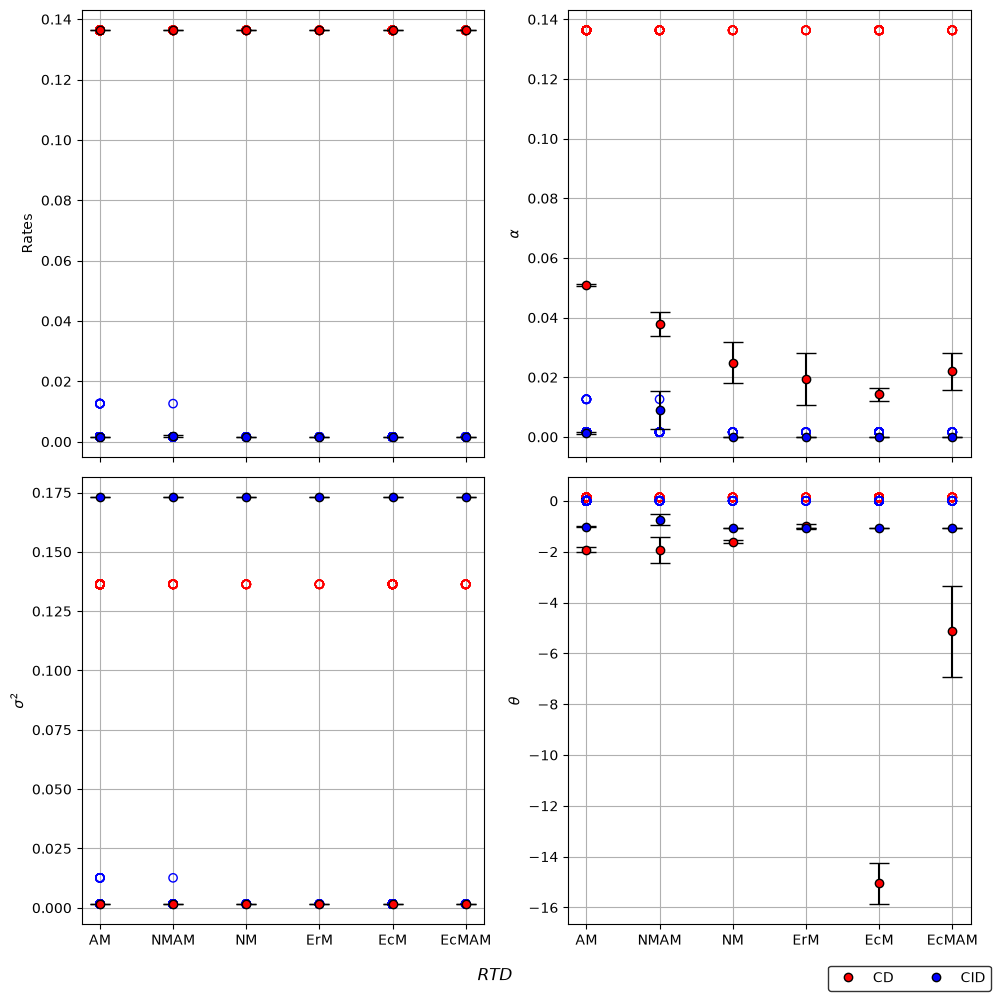

In [139]:
plot_houwie_summary_v2(data=data, trait="RTD")
plt.savefig(r"../../plots/houwieRTD1301_250sims.png", format="png", dpi=800, transparent=True)